# Стохастический Анализ
## Семинар "Модели стохастической волатильности" (25.04.2026)

In [ ]:
!pip install yfinance

In [8]:
import numpy as np
import pandas as pd
import yfinance as yf
from scipy.optimize import minimize
from scipy.stats import norm, nct, ncx2
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

Попробуем применить знания о моделях стохастической волатильности в задаче прайсинга опционов. Для начала откалибруем привычную нам связку GBM + risk-free rate на реальных данных с помощью MLE.


## 1. Постановка задачи

Целью данного занятия является практическая реализация метода максимального правдоподобия (MLE) для оценки параметров двух фундаментальных моделей количественных финансов:
*   **Модель динамики актива (GBM):** Геометрическое броуновское движение для описания эволюции цены рискового актива.
*   **Модель краткосрочной ставки (CIR):** Модель Кокса-Ингерсолла-Росса для описания стохастической динамики безрисковой процентной ставки с учетом свойства невозврата к отрицательным значениям и возврата к среднему.

## 2. Математические модели

### 2.1. Геометрическое броуновское движение (GBM)

Динамика цены актива $S_t$ описывается следующим стохастическим дифференциальным уравнением (СДУ):

$$
dS_t = \mu S_t dt + \sigma S_t dW_t^S
$$

где:
*   $\mu$ — коэффициент дрейфа (ожидаемая доходность),
*   $\sigma$ — волатильность актива,
*   $W_t^S$ — стандартное винеровское движение.

Применяя лемму Ито к $\ln S_t$, получаем решение в явном виде:
$$
S_T = S_0 \exp\left( \left(\mu - \frac{1}{2}\sigma^2\right)T + \sigma W_T^S \right)
$$

Логарифмические доходности $r_t = \ln(S_t / S_{t-\Delta t})$ имеют нормальное распределение:
$$
r_t \sim \mathcal{N}\left( \left(\mu - \frac{1}{2}\sigma^2\right)\Delta t, \; \sigma^2 \Delta t \right)
$$

### 2.2. Модель Кокса-Ингерсолла-Росса (CIR)

Динамика краткосрочной процентной ставки $r_t$ описывается СДУ:

$$
dr_t = \kappa (\theta - r_t) dt + \sigma \sqrt{r_t} dW_t^r
$$

где:
*   $\kappa > 0$ — скорость возврата к среднему,
*   $\theta > 0$ — долгосрочное среднее значение ставки,
*   $\sigma > 0$ — волатильность ставки,
*   $W_t^r$ — стандартное винеровское движение.

**Ключевые свойства:**
1.  **Неотрицательность:** Благодаря множителю $\sqrt{r_t}$ перед шумом, процесс не уходит в отрицательную область (при соблюдении условия Феллера).
2.  **Условие Феллера:** Если $2\kappa\theta \ge \sigma^2$, то нулевая граница недостижима из внутренней области ($r_t > 0$ почти наверное). Если условие нарушено, процесс может достигать нуля, но отражается от него.

Переходная плотность вероятности $p(r_t | r_{t-\Delta t})$ связана с нецентральным хи-квадрат распределением $\chi^2$:
$$
r_t | r_{t-\Delta t} \sim c \cdot \chi^2_d(\lambda)
$$
где параметры распределения зависят от $\kappa, \theta, \sigma$ и шага по времени $\Delta t$.

In [9]:
def load_data():
    """
    Loads S&P 500 data and US 10-Year Treasury Yield data.
    For the interest rate, we use ^TNX (CBOE Interest Rate 10 Year T No) as a proxy.
    Note: ^TNX is in percentage points (e.g., 4.5 means 4.5%). We convert to decimal.
    """
    print("Downloading data...")
    
    # Download S&P 500
    sp500 = yf.download("^GSPC", start="2010-01-01", end="2023-01-01")
    
    # Download 10-Year Treasury Yield (^TNX)
    # Note: ^TNX might have gaps or be unavailable in some yfinance versions. 
    # Alternative: Use FRED library if available, but sticking to yfinance for simplicity.
    try:
        rates = yf.download("^FVX", start="2010-01-01", end="2023-01-01")
        # TNX is in percent, convert to decimal
        rates['Rate'] = rates['Close'] / 100.0
    except Exception as e:
        print(f"Could not download ^TNX: {e}. Using synthetic data for demonstration.")
        # Fallback to synthetic data if download fails
        dates = sp500.index
        n = len(dates)
        dt = 1/252
        r = np.zeros(n)
        r[0] = 0.02
        kappa, theta, sigma_r = 0.5, 0.03, 0.01
        for i in range(1, n):
            dz = np.random.normal(0, np.sqrt(dt))
            dr = kappa * (theta - r[i-1]) * dt + sigma_r * np.sqrt(r[i-1]) * dz
            r[i] = r[i-1] + dr
        rates = pd.DataFrame(index=dates)
        rates['Rate'] = r

    # Align data
    df = pd.merge(sp500[['Close']], rates[['Rate']], left_index=True, right_index=True, how='inner')
    df = df.dropna()
    df.columns = ['SnP500', 'rate']
    df = df.reset_index()
    
    return df


# Грузим данные из Yfinance
df = load_data()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [10]:
df.head()

,Date,SnP500,rate
0,2010-01-04,1132.989990,0.02652
1,2010-01-05,1136.520020,0.02558
2,2010-01-06,1137.140015,0.02573
3,2010-01-07,1141.689941,0.02600
4,2010-01-08,1144.979980,0.02566


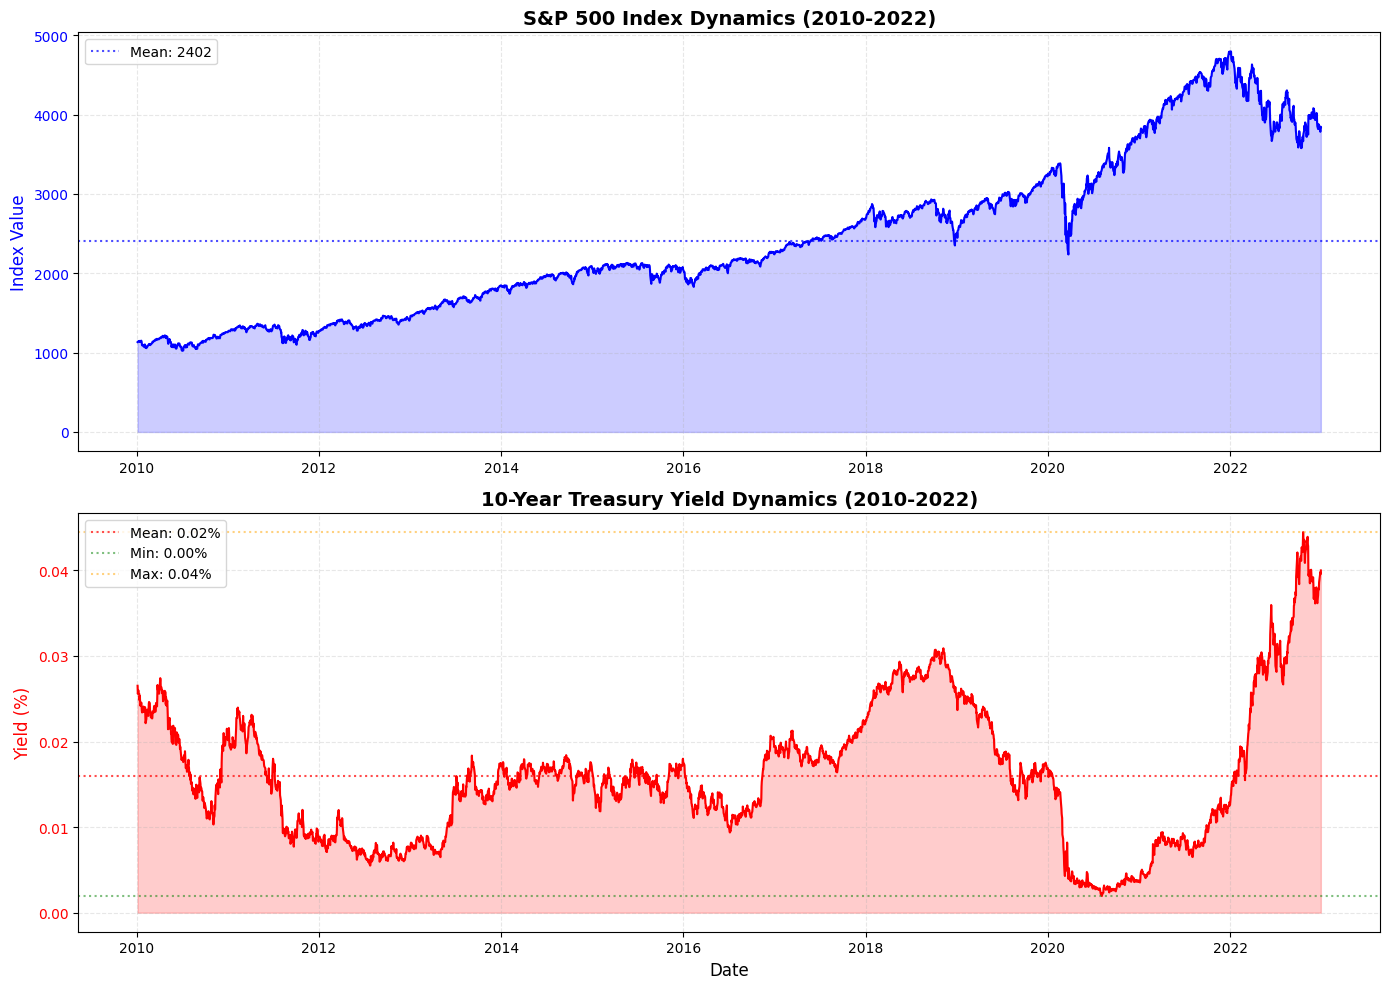

In [11]:
# Отрисуем динамику 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

ax1.plot(df['Date'], df['SnP500'], color='blue', linewidth=1.5)
ax1.set_title('S&P 500 Index Dynamics (2010-2022)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Index Value', fontsize=12, color='blue')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.tick_params(axis='y', labelcolor='blue')

sp500_mean = df['SnP500'].mean()
ax1.axhline(y=sp500_mean, color='blue', linestyle=':', alpha=0.7, 
            label=f'Mean: {sp500_mean:.0f}')
ax1.legend(loc='upper left')

ax1.fill_between(df['Date'], df['SnP500'], alpha=0.2, color='blue')

ax2.plot(df['Date'], df['rate'], color='red', linewidth=1.5)
ax2.set_title('10-Year Treasury Yield Dynamics (2010-2022)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Yield (%)', fontsize=12, color='red')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.tick_params(axis='y', labelcolor='red')
rate_min = df['rate'].min()
rate_max = df['rate'].max()
rate_mean = df['rate'].mean()

ax2.axhline(y=rate_mean, color='red', linestyle=':', alpha=0.7, 
            label=f'Mean: {rate_mean:.2f}%')
ax2.axhline(y=rate_min, color='green', linestyle=':', alpha=0.5, 
            label=f'Min: {rate_min:.2f}%')
ax2.axhline(y=rate_max, color='orange', linestyle=':', alpha=0.5, 
            label=f'Max: {rate_max:.2f}%')
ax2.legend(loc='upper left')

ax2.fill_between(df['Date'], df['rate'], alpha=0.2, color='red')

plt.tight_layout()
plt.show()

## Метод максимального правдоподобия (MLE) для модели CIR

Для оценки параметров модели Кокса-Ингерсолла-Росса (CIR) $\Theta = (\kappa, \theta, \sigma)$ мы используем метод максимального правдоподобия. Преимущество подхода заключается в использовании **точного переходного распределения** процесса, а не его аппроксимации (как в методе Эйлера-Маруямы), что обеспечивает несмещенность оценок даже при больших шагах дискретизации $\Delta t$.

### 1. Точное переходное распределение

Известно, что условное распределение ставки $r_t$ при известном $r_s$ ($t > s$) в модели CIR пропорционально нецентральному хи-квадрат распределению:

$$
r_t | r_s \sim c \cdot \chi^2_d(\lambda)
$$

где параметры распределения определяются следующим образом:

*   **Масштабный коэффициент:**
    $$
    c = \frac{\sigma^2 (1 - e^{-\kappa \Delta t})}{4 \kappa}
    $$
*   **Степени свободы:**
    $$
    d = \frac{4 \kappa \theta}{\sigma^2}
    $$
*   **Параметр нецентральности:**
    $$
    \lambda = \frac{4 \kappa e^{-\kappa \Delta t}}{\sigma^2 (1 - e^{-\kappa \Delta t})} r_s
    $$

Здесь $\Delta t = t - s$ — шаг по времени (в наших данных $\Delta t = 1/252$ года).

### 2. Функция правдоподобия

Пусть у нас есть наблюдение ставок $r_0, r_1, \dots, r_N$. Поскольку процесс Марковский, совместная плотность вероятности наблюдений раскладывается в произведение условных плотностей переходов:

$$
L(\Theta) = p(r_0) \prod_{i=1}^{N} p(r_i | r_{i-1}; \Theta)
$$

Пренебрегая первым членом $p(r_0)$ (так как $N$ велико), логарифмическая функция правдоподобия имеет вид:

$$
\ln L(\Theta) = \sum_{i=1}^{N} \ln p(r_i | r_{i-1}; \Theta)
$$

Плотность перехода $p(r_i | r_{i-1})$ выражается через плотность нецентрального хи-квадрат распределения $f_{\chi^2}(x; d, \lambda)$ с учетом якобиана преобразования масштаба $c$:

$$
p(r_i | r_{i-1}) = \frac{1}{c} f_{\chi^2}\left( \frac{r_i}{c}; d, \lambda \right)
$$

Таким образом, вклад $i$-го наблюдения в логарифмическое правдоподобие:

$$
\ln p(r_i | r_{i-1}) = -\ln c + \ln f_{\chi^2}\left( \frac{r_i}{c}; d, \lambda \right)
$$

### 3. Процедура оптимизации

Мы ищем параметры $\hat{\Theta}$, максимизирующие логарифмическое правдоподобие:

$$
\hat{\Theta} = \arg \max_{\kappa, \theta, \sigma} \ln L(\kappa, \theta, \sigma)
$$

На практике минимизируется отрицательное логарифмическое правдоподобие (Negative Log-Likelihood, NLL) с использованием численных методов (например, L-BFGS-B) при ограничениях $\kappa > 0, \theta > 0, \sigma > 0$.

### 4. Проверка условия Феллера

После калибровки важно проверить условие Феллера:
$$
2 \kappa \theta \ge \sigma^2
$$
Если условие выполняется, нулевая граница недостижима ($r_t > 0$ почти наверное). Если $2 \kappa \theta < \sigma^2$, процесс может достигать нуля, но остается неотрицательным. Это влияет на выбор численных схем при дальнейшем моделировании траекторий.

In [12]:
# Откалибруем CIR

class CIRModel:
    def __init__(self, rates, dt=1/252):
        self.rates = rates.values
        self.dt = dt
        self.n = len(rates)
        self.kappa = None
        self.theta = None
        self.sigma = None
        
    def _cir_transition_loglik(self, r_prev, r_curr, kappa, theta, sigma, dt):
        """
        Computes the log-likelihood of the transition r_prev -> r_curr under CIR.
        """
        if kappa <= 0 or theta <= 0 or sigma <= 0:
            return -1e6
            
        exp_kdt = np.exp(-kappa * dt)
        
        c = (sigma**2 * (1 - exp_kdt)) / (4 * kappa)
        d = (4 * kappa * theta) / (sigma**2)
        lam = (4 * kappa * exp_kdt * r_prev) / (sigma**2 * (1 - exp_kdt))
        
        if c <= 0:
            return -1e6
        if lam < 0:
            lam = 0
            
        x = r_curr / c
        
        if x < 0:
            return -1e6
            
        try:
            pdf_val = ncx2.pdf(x, d, lam)
            if pdf_val <= 0:
                return -1e6
            log_pdf_x = np.log(pdf_val)
            log_jacobian = -np.log(c)
            return log_pdf_x + log_jacobian
        except Exception:
            return -1e6

    def neg_log_likelihood(self, params):
        kappa, theta, sigma = params
        
        if kappa <= 0 or theta <= 0 or sigma <= 0:
            return 1e6
            
        total_ll = 0
        for i in range(1, self.n):
            r_prev = self.rates[i-1]
            r_curr = self.rates[i]
            ll_i = self._cir_transition_loglik(r_prev, r_curr, kappa, theta, sigma, self.dt)
            total_ll += ll_i
            
        return -total_ll

    def calibrate(self):
        initial_params = [0.5, 0.05, 0.01]
        bounds = [(1e-6, None), (1e-6, None), (1e-6, None)]
        
        result = minimize(self.neg_log_likelihood, initial_params, bounds=bounds, method='L-BFGS-B', options={'maxiter': 1000})
        
        if result.success:
            self.kappa, self.theta, self.sigma = result.x
            print(f"CIR Calibration Successful:")
            print(f"  Kappa (Mean Reversion): {self.kappa:.4f}")
            print(f"  Theta (Long-term Mean): {self.theta:.4f}")
            print(f"  Sigma (Vol of Vol): {self.sigma:.4f}")
            feller = 2 * self.kappa * self.theta / (self.sigma**2)
            print(f"  Feller Condition (2*kappa*theta/sigma^2): {feller:.4f} {'(Valid)' if feller > 1 else '(Boundary Crossing Possible)'}")
        else:
            print("CIR Calibration Failed:", result.message)
            
        return result

    def simulate_future(self, history_points, future_steps, n_simulations=100):
        """
        Simulates future trajectories of the CIR process starting from the last observed point.
        
        Parameters:
        -----------
        history_points : array-like
            The historical data points (used for plotting context).
        future_steps : int
            Number of steps to simulate into the future.
        n_simulations : int
            Number of simulation paths to generate.
            
        Returns:
        --------
        history : np.array
            The input history points.
        simulations : np.array
            Array of shape (n_simulations, future_steps) containing simulated paths.
        """
        if self.kappa is None or self.theta is None or self.sigma is None:
            raise ValueError("Model must be calibrated before simulation. Call calibrate() first.")
        
        r_current = history_points[-1]
        dt = self.dt
        kappa = self.kappa
        theta = self.theta
        sigma = self.sigma
        
        # Pre-allocate array for simulations
        simulations = np.zeros((n_simulations, future_steps))
        
        # Exact simulation scheme using Non-Central Chi-Squared distribution
        # r(t+dt) | r(t) ~ c * chi^2(d, lambda)
        
        exp_kdt = np.exp(-kappa * dt)
        c = (sigma**2 * (1 - exp_kdt)) / (4 * kappa)
        d = (4 * kappa * theta) / (sigma**2)
        
        r_prev = np.full(n_simulations, r_current)
        
        for step in range(future_steps):
            # Calculate lambda for each path based on previous step value
            # Ensure r_prev is non-negative for lambda calculation
            r_prev_safe = np.maximum(r_prev, 0)
            lam = (4 * kappa * exp_kdt * r_prev_safe) / (sigma**2 * (1 - exp_kdt))
            
            # Generate random variates from non-central chi-squared
            # ncx2.rvs returns samples of shape (n_simulations,)
            chi2_samples = ncx2.rvs(df=d, nc=lam, size=n_simulations)
            
            # Transform back to rate
            r_next = c * chi2_samples
            
            # Store results
            simulations[:, step] = r_next
            
            # Update previous value for next step
            r_prev = r_next
            
        return np.array(history_points), simulations

    def summary(self):
        """
        Prints a formatted summary of the calibrated CIR model equation.
        """
        if self.kappa is None or self.theta is None or self.sigma is None:
            return "Model not calibrated yet."
        
        summary_str = (
            f"--- Calibrated CIR Model Summary ---\n"
            f"Stochastic Differential Equation:\n"
            f"  dr_t = κ(θ - r_t)dt + σ√r_t dW_t\n\n"
            f"Calibrated Parameters:\n"
            f"  κ (Mean Reversion Speed) = {self.kappa:.4f}\n"
            f"  θ (Long-term Mean)       = {self.theta:.4f}\n"
            f"  σ (Volatility)           = {self.sigma:.4f}\n\n"
            f"Explicit Form:\n"
            f"  dr_t = {self.kappa:.4f} * ({self.theta:.4f} - r_t)dt + {self.sigma:.4f} * √r_t dW_t\n"
            f"----------------------------------"
        )
        print(summary_str)

In [13]:
CIR = CIRModel(df.rate, 1/252)

In [14]:
CIR.calibrate()

CIR Calibration Successful:
  Kappa (Mean Reversion): 0.3093
  Theta (Long-term Mean): 0.0194
  Sigma (Vol of Vol): 0.0646
  Feller Condition (2*kappa*theta/sigma^2): 2.8711 (Valid)


  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -20348.43008735717
        x: [ 3.093e-01  1.936e-02  6.460e-02]
      nit: 25
      jac: [ 3.638e-04  1.019e-01  2.135e-01]
     nfev: 172
     njev: 43
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>

In [15]:
# 1. Вывод формулы
CIR.summary()

--- Calibrated CIR Model Summary ---
Stochastic Differential Equation:
  dr_t = κ(θ - r_t)dt + σ√r_t dW_t

Calibrated Parameters:
  κ (Mean Reversion Speed) = 0.3093
  θ (Long-term Mean)       = 0.0194
  σ (Volatility)           = 0.0646

Explicit Form:
  dr_t = 0.3093 * (0.0194 - r_t)dt + 0.0646 * √r_t dW_t
----------------------------------


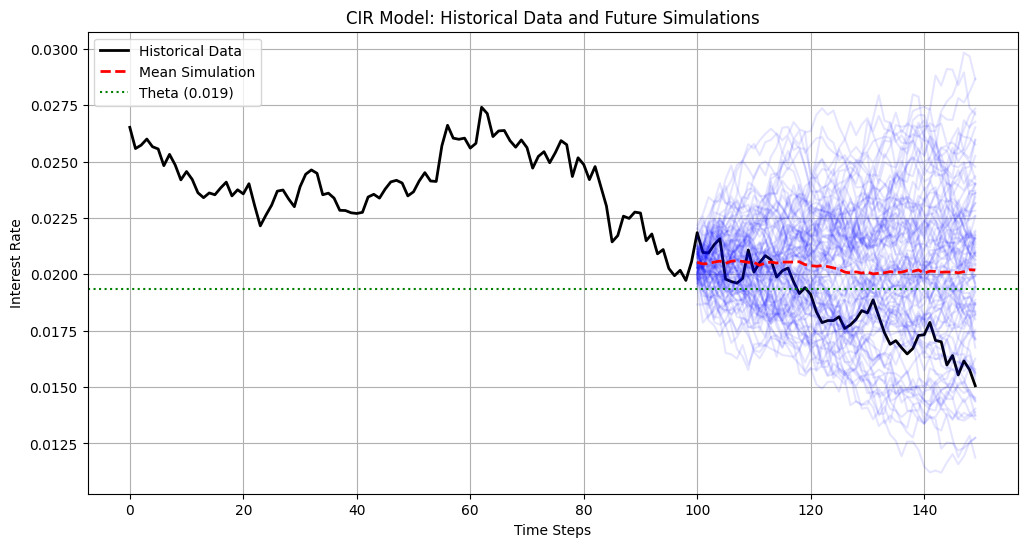

In [16]:
# Допустим, мы хотим продолжить график на 50 шагов вперед, сделав 100 симуляций
history_data = df['rate'][:100].values # Или любой другой массив исторических данных
n_future_steps = 50
n_sims = 100

# Получаем данные
hist, sims = CIR.simulate_future(history_data, n_future_steps, n_sims)

plot_data = df['rate'][:100 + n_future_steps].values
# Визуализация
plt.figure(figsize=(12, 6))
# Plot history
t_hist = np.arange(len(plot_data))
plt.plot(t_hist, plot_data, label='Historical Data', color='black', linewidth=2)

# Plot simulations
t_future = np.arange(len(hist), len(hist) + n_future_steps)
for i in range(n_sims):
    plt.plot(t_future, sims[i], alpha=0.1, color='blue') # Полупрозрачные линии

# Plot mean of simulations
mean_sim = np.mean(sims, axis=0)
plt.plot(t_future, mean_sim, label='Mean Simulation', color='red', linestyle='--', linewidth=2)

# Add horizontal line for Theta
plt.axhline(y=CIR.theta, color='green', linestyle=':', label=f'Theta ({CIR.theta:.3f})')

plt.title('CIR Model: Historical Data and Future Simulations')
plt.xlabel('Time Steps')
plt.ylabel('Interest Rate')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
class GBMWithRateModel:
    def __init__(self, prices, rates, dt=1/252):
        self.prices = prices.values
        self.rates = rates.values # Array of r_t
        self.dt = dt
        self.n = len(prices)
        
        # Log returns: y_t = ln(S_t / S_{t-1})
        self.log_returns = np.diff(np.log(self.prices))
        
        # We need r_{t-1} for the drift at time t. 
        # So we align rates[:-1] with log_returns
        self.rates_lag = self.rates[:-1]

    def neg_log_likelihood(self, params):
        alpha, beta, sigma = params
        
        if sigma <= 0:
            return 1e6
            
        # Drift term: mu_t = alpha + beta * r_{t-1}
        # Mean of log return: (mu_t - 0.5 * sigma^2) * dt
        drifts = (alpha + beta * self.rates_lag - 0.5 * sigma**2) * self.dt
        std_dev = sigma * np.sqrt(self.dt)
        
        # Calculate log-likelihood for each observation
        ll = np.sum(norm.logpdf(self.log_returns, loc=drifts, scale=std_dev))
        return -ll

    def calibrate(self):
        # Initial guesses: alpha=0.05, beta=0.5, sigma=0.2
        # If beta=0, it reduces to standard GBM with constant drift alpha
        initial_params = [0.05, 0.5, 0.2]
        bounds = [(None, None), (None, None), (1e-6, None)]
        
        result = minimize(self.neg_log_likelihood, initial_params, bounds=bounds, method='L-BFGS-B')
        
        if result.success:
            self.alpha, self.beta, self.sigma = result.x
            print(f"GBM-SR Calibration Successful:")
            print(f"  Alpha (Base Drift): {self.alpha:.4f}")
            print(f"  Beta (Rate Sensitivity): {self.beta:.4f}")
            print(f"  Sigma (Volatility): {self.sigma:.4f}")
            
            # Interpretation
            if abs(self.beta) < 0.1:
                print("  Note: Beta is close to 0. Drift is nearly constant (standard GBM).")
            else:
                print(f"  Note: Drift depends on rate. mu_t = {self.alpha:.4f} + {self.beta:.4f} * r_t")
        else:
            print("GBM-SR Calibration Failed:", result.message)
            
        return result

## Метод максимального правдоподобия (MLE) для модели GBM с зависимостью от ставки

Для оценки параметров модели геометрического броуновского движения, дрейф которого зависит от процентной ставки ($\mu_t = \alpha + \beta r_t$), мы используем метод максимального правдоподобия.

### 1. Динамика модели

Рассматриваемая модель описывается следующим стохастическим дифференциальным уравнением:

$$
\frac{dS_t}{S_t} = (\alpha + \beta r_t) dt + \sigma dW_t
$$

где:
*   $S_t$ — цена актива в момент времени $t$,
*   $r_t$ — безрисковая процентная ставка в момент времени $t$,
*   $\alpha$ — базовый уровень доходности (константа),
*   $\beta$ — чувствительность доходности актива к изменению процентной ставки,
*   $\sigma$ — волатильность актива,
*   $W_t$ — стандартное винеровское процесс.

### 2. Переходная плотность

Применяя лемму Ито к $\ln S_t$, получаем динамику логарифма цены:

$$
d(\ln S_t) = \left( \alpha + \beta r_t - \frac{1}{2}\sigma^2 \right) dt + \sigma dW_t
$$

Для дискретного наблюдения с шагом $\Delta t$ логарифмическая доходность $y_t = \ln(S_t / S_{t-1})$ имеет нормальное распределение:

$$
y_t | r_{t-1} \sim \mathcal{N}\left( \mu_t \Delta t, \; \sigma^2 \Delta t \right)
$$

где условное математическое ожидание определяется как:
$$
\mu_t = \alpha + \beta r_{t-1} - \frac{1}{2}\sigma^2
$$

### 3. Функция правдоподобия

Пусть у нас есть набор наблюдений логарифмических доходностей $y_1, \dots, y_N$ и соответствующих им ставок $r_0, \dots, r_{N-1}$. Поскольку приращения винеровского процесса независимы, совместная функция правдоподобия равна произведению плотностей отдельных наблюдений:

$$
L(\alpha, \beta, \sigma) = \prod_{t=1}^{N} \frac{1}{\sqrt{2\pi \sigma^2 \Delta t}} \exp\left( -\frac{(y_t - (\alpha + \beta r_{t-1} - 0.5\sigma^2)\Delta t)^2}{2\sigma^2 \Delta t} \right)
$$

Логарифмическая функция правдоподобия (Log-Likelihood):

$$
\ln L(\alpha, \beta, \sigma) = -\frac{N}{2} \ln(2\pi \sigma^2 \Delta t) - \sum_{t=1}^{N} \frac{(y_t - (\alpha + \beta r_{t-1} - 0.5\sigma^2)\Delta t)^2}{2\sigma^2 \Delta t}
$$

In [18]:
class GBMWithRateModel:
    def __init__(self, prices, rates, dt=1/252):
        # Преобразуем входные данные в numpy массивы для надежности
        if isinstance(prices, pd.Series) or isinstance(prices, pd.DataFrame):
            self.prices = prices.values.flatten()
        else:
            self.prices = np.array(prices).flatten()
            
        if isinstance(rates, pd.Series) or isinstance(rates, pd.DataFrame):
            self.rates = rates.values.flatten()
        else:
            self.rates = np.array(rates).flatten()
            
        self.dt = dt
        self.n = len(self.prices)
        
        # Log returns: y_t = ln(S_t / S_{t-1})
        # Длина log_returns будет n-1
        self.log_returns = np.diff(np.log(self.prices))
        
        # We need r_{t-1} for the drift at time t. 
        # So we align rates[:-1] with log_returns
        # Длина rates_lag также будет n-1
        self.rates_lag = self.rates[:-1]
        
        # Параметры модели (инициализируются как None до калибровки)
        self.alpha = None
        self.beta = None
        self.sigma = None

    def neg_log_likelihood(self, params):
        alpha, beta, sigma = params
        
        if sigma <= 0:
            return 1e6
            
        # Drift term: mu_t = alpha + beta * r_{t-1}
        # Mean of log return: (mu_t - 0.5 * sigma^2) * dt
        drifts = (alpha + beta * self.rates_lag - 0.5 * sigma**2) * self.dt
        std_dev = sigma * np.sqrt(self.dt)
        
        # Calculate log-likelihood for each observation
        # Используем sum, так как наблюдения независимы при заданных параметрах
        ll = np.sum(norm.logpdf(self.log_returns, loc=drifts, scale=std_dev))
        return -ll

    def calibrate(self):
        # Initial guesses: alpha=0.05, beta=0.5, sigma=0.2
        initial_params = [0.05, 0.5, 0.2]
        bounds = [(None, None), (None, None), (1e-6, None)]
        
        result = minimize(self.neg_log_likelihood, initial_params, bounds=bounds, method='L-BFGS-B')
        
        if result.success:
            self.alpha, self.beta, self.sigma = result.x
            print(f"GBM-SR Calibration Successful:")
            print(f"  Alpha (Base Drift): {self.alpha:.4f}")
            print(f"  Beta (Rate Sensitivity): {self.beta:.4f}")
            print(f"  Sigma (Volatility): {self.sigma:.4f}")
            
            # Interpretation
            if abs(self.beta) < 0.1:
                print("  Note: Beta is close to 0. Drift is nearly constant (standard GBM).")
            else:
                print(f"  Note: Drift depends on rate. mu_t = {self.alpha:.4f} + {self.beta:.4f} * r_t")
        else:
            print("GBM-SR Calibration Failed:", result.message)
            
        return result

    def simulate_future(self, history_prices, future_steps, n_simulations=100, future_rates=None):
        """
        Simulates future price trajectories based on the calibrated GBM-SR model.
        
        Parameters:
        -----------
        history_prices : array-like
            Historical prices to start the simulation from.
        future_steps : int
            Number of steps to simulate.
        n_simulations : int
            Number of paths to generate.
        future_rates : array-like, optional
            Future interest rates for each step. If None, uses the last observed rate.
            
        Returns:
        --------
        hist_arr : np.array
            Historical prices.
        simulations : np.array
            Array of shape (n_simulations, future_steps + 1) including the start point.
        """
        if self.alpha is None or self.beta is None or self.sigma is None:
            raise ValueError("Model must be calibrated before simulation. Call calibrate() first.")
        
        # Ensure history is numpy array
        if isinstance(history_prices, pd.Series) or isinstance(history_prices, pd.DataFrame):
            hist_arr = history_prices.values.flatten()
        else:
            hist_arr = np.array(history_prices).flatten()
            
        s_current = hist_arr[-1]
        
        # Prepare rates for simulation
        if future_rates is not None:
            if isinstance(future_rates, pd.Series) or isinstance(future_rates, pd.DataFrame):
                sim_rates = future_rates.values.flatten()
            else:
                sim_rates = np.array(future_rates).flatten()
                
            if len(sim_rates) < future_steps:
                # If not enough rates provided, pad with the last one
                last_r = sim_rates[-1]
                padding = np.full(future_steps - len(sim_rates), last_r)
                sim_rates = np.concatenate([sim_rates, padding])
            # Use only the needed steps
            sim_rates = sim_rates[:future_steps]
        else:
            # Use constant rate equal to the last observed historical rate
            last_hist_rate = self.rates[-1]
            sim_rates = np.full(future_steps, last_hist_rate)
            
        # Initialize simulations array
        # Shape: (n_simulations, future_steps + 1) to include start price
        simulations = np.zeros((n_simulations, future_steps + 1))
        simulations[:, 0] = s_current
        
        dt = self.dt
        alpha = self.alpha
        beta = self.beta
        sigma = self.sigma
        
        # Simulate step by step
        for t in range(future_steps):
            r_t = sim_rates[t]
            
            # Drift for this step: mu_t = alpha + beta * r_t
            mu_t = alpha + beta * r_t
            
            # GBM Step: S_{t+1} = S_t * exp((mu_t - 0.5*sigma^2)*dt + sigma*sqrt(dt)*Z)
            drift_term = (mu_t - 0.5 * sigma**2) * dt
            diffusion_term = sigma * np.sqrt(dt) * np.random.normal(0, 1, size=n_simulations)
            
            # Update prices
            simulations[:, t+1] = simulations[:, t] * np.exp(drift_term + diffusion_term)
            
        return hist_arr, simulations

    def summary(self):
        """
        Prints a formatted summary of the calibrated GBM-SR model equation.
        """
        if self.alpha is None or self.beta is None or self.sigma is None:
            return "Model not calibrated yet."
        
        summary_str = (
            f"--- Calibrated GBM-SR Model Summary ---\n"
            f"Stochastic Differential Equation:\n"
            f"  dS_t / S_t = (α + β*r_t)dt + σ dW_t\n\n"
            f"Calibrated Parameters:\n"
            f"  α (Base Drift)           = {self.alpha:.4f}\n"
            f"  β (Rate Sensitivity)     = {self.beta:.4f}\n"
            f"  σ (Volatility)           = {self.sigma:.4f}\n\n"
            f"Explicit Form:\n"
            f"  dS_t / S_t = ({self.alpha:.4f} + {self.beta:.4f}*r_t)dt + {self.sigma:.4f} dW_t\n"
            f"----------------------------------"
        )
        print(summary_str)

In [19]:
GBM = GBMWithRateModel(df.SnP500, df.rate, 1/252)

In [20]:
GBM.calibrate()

GBM-SR Calibration Successful:
  Alpha (Base Drift): 0.1020
  Beta (Rate Sensitivity): 0.5000
  Sigma (Volatility): 0.1787
  Note: Drift depends on rate. mu_t = 0.1020 + 0.5000 * r_t


  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -10028.654032971186
        x: [ 1.020e-01  5.000e-01  1.787e-01]
      nit: 6
      jac: [-3.274e-03  3.682e-01 -4.839e-02]
     nfev: 40
     njev: 10
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>

In [21]:
GBM.summary()

--- Calibrated GBM-SR Model Summary ---
Stochastic Differential Equation:
  dS_t / S_t = (α + β*r_t)dt + σ dW_t

Calibrated Parameters:
  α (Base Drift)           = 0.1020
  β (Rate Sensitivity)     = 0.5000
  σ (Volatility)           = 0.1787

Explicit Form:
  dS_t / S_t = (0.1020 + 0.5000*r_t)dt + 0.1787 dW_t
----------------------------------


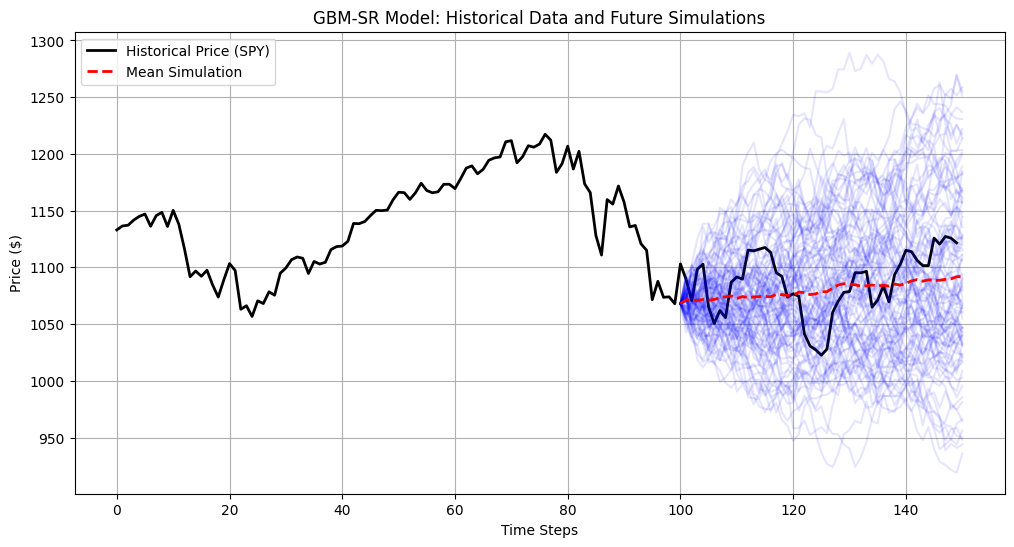

In [22]:
# Нарисуем GBM с реальной ставкой
history_prices = df['SnP500'].values[:100] 

n_future_steps = 50
n_sims = 100

plot_data = df['SnP500'][:100 + n_future_steps].values

# 2. Запуск симуляции
# Важно: передаем именно цены (Close), а не ставки
hist_arr, sims = GBM.simulate_future(
    history_prices=history_prices, 
    future_steps=n_future_steps, 
    n_simulations=n_sims,
    future_rates=None 
)

# 3. Визуализация
plt.figure(figsize=(12, 6))

# --- Plot History ---
t_hist = np.arange(len(plot_data))
plt.plot(t_hist, plot_data, label='Historical Price (SPY)', color='black', linewidth=2)

# --- Plot Simulations ---
# Время для будущей части начинается с конца истории
t_future = np.arange(len(hist_arr), len(hist_arr) + n_future_steps + 1)

for i in range(n_sims):
    plt.plot(t_future, sims[i], alpha=0.1, color='blue') # Полупрозрачные линии траекторий

# --- Plot Mean Simulation ---
mean_sim = np.mean(sims, axis=0)
plt.plot(t_future, mean_sim, label='Mean Simulation', color='red', linestyle='--', linewidth=2)

# --- Annotations ---
plt.title('GBM-SR Model: Historical Data and Future Simulations')
plt.xlabel('Time Steps')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)

plt.show()

# Калибровка модели Хестона: Алгоритм и Функция Правдоподобия
 
Попробуем теперь оценить модель Хестона. 

## 1. Исходные данные и предобработка

Имеются временные ряды:
*   $S_t$: Цена S&P 500.
*   $r_t$: Доходность 5-летних казначейских облигаций (безрисковая ставка).

**Шаги подготовки:**
1.  Вычислить лог-доходности актива: $y_t = \ln(S_t / S_{t-1})$.
2.  Согласовать частоту данных $r_t$ с $S_t$ (интерполяция или forward-fill).
3.  Определить избыточные доходности: $\tilde{y}_t = y_t - r_t \Delta t$, где $\Delta t$ — шаг по времени (например, $1/252$).

## 2. Модель Хестона

Динамика под реальной мерой $\mathbb{P}$:
$$
\begin{aligned}
dS_t &= r_t S_t dt + \sqrt{v_t} S_t dW_t^S, \\
dv_t &= \kappa (\theta - v_t) dt + \xi \sqrt{v_t} dW_t^v,
\end{aligned}
$$
с корреляцией $d\langle W^S, W^v \rangle_t = \rho dt$.

Параметры для оценки: $\Theta = (\kappa, \theta, \xi, \rho, v_0)$.

> **Примечание:** Так как волатильность $v_t$ ненаблюдаема, для вычисления правдоподобия необходимо использовать методы фильтрации скрытых состояний. Наиболее распространенным подходом в данном контексте является использование **Фильтра Калмана** (в частности, его нелинейных версий, таких как Extended Kalman Filter или Unscented Kalman Filter), который позволяет рекуррентно оценивать скрытое состояние $v_t$ и вычислять плотность вероятности наблюдений.

## 3. Алгоритм калибровки (MLE)

Основная идея заключается в максимизации функции правдоподобия наблюдаемых доходностей $\tilde{y}_1, \dots, \tilde{y}_T$ при заданных параметрах $\Theta$.

### Функция правдоподобия

Логарифмическая функция правдоподобия записывается как сумма условных лог-плотностей:

$$
\mathcal{L}(\Theta) = \sum_{t=1}^{T} \ln p(\tilde{y}_t | \mathcal{F}_{t-1}; \Theta)
$$

где $p(\tilde{y}_t | \mathcal{F}_{t-1}; \Theta)$ — плотность распределения доходности в момент $t$, предсказанная моделью на основе информации, доступной до момента $t-1$.

При использовании фильтра Калмана эта плотность обычно предполагается гауссовской (или аппроксимируется таковой):
$$
\ln p(\tilde{y}_t | \mathcal{F}_{t-1}; \Theta) = -\frac{1}{2} \left( \ln(2\pi) + \ln(F_t) + \frac{\nu_t^2}{F_t} \right)
$$
где:
*   $\nu_t = \tilde{y}_t - \mathbb{E}[\tilde{y}_t | \mathcal{F}_{t-1}]$ — инновация (ошибка предсказания).
*   $F_t = \text{Var}(\tilde{y}_t | \mathcal{F}_{t-1})$ — дисперсия ошибки предсказания.

Эти величины ($\nu_t$ и $F_t$) вычисляются на шаге обновления фильтра Калмана для каждого момента времени $t$.

### Шаги оптимизации

1.  **Инициализация:** Выбрать начальные значения параметров $\Theta_0$ и задать границы (например, $\kappa, \theta, \xi, v_0 > 0$, $|\rho| < 1$).
2.  **Цикл фильтрации:** Для текущего набора $\Theta$:
    *   Запустить фильтр Калмана (EKF/UKF) по ряду $\tilde{y}_t$.
    *   На каждом шаге $t$ сохранить инновацию $\nu_t$ и её дисперсию $F_t$.
    *   Вычислить суммарное лог-правдоподобие $\mathcal{L}(\Theta)$.
3.  **Оптимизация:** Использовать численный метод (например, `L-BFGS-B` или `Nelder-Mead` из `scipy.optimize`) для поиска $\Theta^*$, максимизирующего $\mathcal{L}(\Theta)$.
4.  **Результат:** Полученные параметры $\Theta^*$ являются оценками максимального правдоподобия.

In [23]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import warnings
import matplotlib.pyplot as plt

class HestonModel:
    def __init__(self, prices, rates, dt=1/252):
        """
        Parameters:
        -----------
        prices : array-like
            Historical prices of the underlying asset (S&P 500).
        rates : array-like
            Historical risk-free rates (5Y Treasury).
        dt : float
            Time step (default 1/252 for daily data).
        """
        self.prices = np.array(prices, dtype=np.float64)
        self.rates = np.array(rates, dtype=np.float64)
        self.dt = dt
        self.n_obs = len(self.prices) - 1
        
        # Log-returns and excess returns
        self.log_returns = np.diff(np.log(self.prices))
        # Align rates: rate at t+1 applies to return from t to t+1
        self.excess_returns = self.log_returns - self.rates[1:] * self.dt
        
        # Calibrated parameters storage
        self.kappa = None
        self.theta = None
        self.xi = None
        self.rho = None
        self.v0 = None
        
        # Optimization history
        self.optimization_result = None

    def _compute_log_likelihood(self, params):
        """
        Computes log-likelihood using Extended Kalman Filter (EKF) approximation.
        """
        kappa, theta, xi, rho, v0 = params
        
        # Constraints check
        if kappa <= 0 or theta <= 0 or xi <= 0 or v0 <= 0 or abs(rho) >= 1:
            return -1e10
            
        T = len(self.excess_returns)
        log_lik = 0
        
        # Initial state
        v_filt = v0
        P_filt = 0.1 # Initial uncertainty
        
        for t in range(T):
            # 1. Prediction Step for Variance (EKF linearization)
            # f(v) = v + kappa*(theta - v)*dt
            F = 1 - kappa * self.dt
            v_pred = v_filt + kappa * (theta - v_filt) * self.dt
            P_pred = F * P_filt * F + xi**2 * v_filt * self.dt # Process noise approx
            
            if P_pred < 1e-12: P_pred = 1e-12
            if v_pred < 1e-12: v_pred = 1e-12

            # 2. Measurement Update / Likelihood Calculation
            # Model: excess_ret = -0.5*v*dt + sqrt(v*dt)*Z_s
            mu_excess = -0.5 * v_pred * self.dt
            var_y = v_pred * self.dt
            
            if var_y < 1e-12: var_y = 1e-12
            
            nu = self.excess_returns[t] - mu_excess
            
            # Log-likelihood contribution
            log_lik += -0.5 * (np.log(2 * np.pi) + np.log(var_y) + (nu**2) / var_y)
            
            # 3. Update Step for Variance (EKF)
            # Cov(dy, dv) approx xi * v * dt * rho
            cov_yv = rho * xi * v_pred * self.dt
            K = cov_yv / var_y # Kalman Gain
            
            v_filt = v_pred + K * nu
            P_filt = (1 - K * cov_yv / var_y) * P_pred 
            
            # Enforce positivity
            if v_filt < 1e-12: v_filt = 1e-12
            if P_filt < 1e-12: P_filt = 1e-12
            
        return -log_lik # Minimize negative log-likelihood

    def calibrate(self):
        """
        Calibrates the Heston model parameters using Maximum Likelihood Estimation.
        Stores results in class attributes.
        """
        # Initial guesses
        realized_var = np.var(self.log_returns[:10]) / self.dt
        if realized_var < 1e-8: realized_var = 0.04
        
        x0 = [2.0, 0.04, 0.3, -0.7, realized_var]
        
        bounds = [
            (1e-4, 10.0),   # kappa
            (1e-4, 1.0),    # theta
            (1e-4, 2.0),    # xi
            (-0.99, 0.99),  # rho
            (1e-4, 1.0)     # v0
        ]
        
        try:
            result = minimize(
                self._compute_log_likelihood,
                x0,
                method='L-BFGS-B',
                bounds=bounds,
                options={'maxiter': 1000, 'ftol': 1e-8}
            )
            
            if result.success:
                self.kappa, self.theta, self.xi, self.rho, self.v0 = result.x
                self.optimization_result = result
            else:
                warnings.warn(f"Optimization failed: {result.message}")
                self.kappa, self.theta, self.xi, self.rho, self.v0 = result.x
                
        except Exception as e:
            raise RuntimeError(f"Calibration error: {str(e)}")

    def summary(self):
        """
        Prints a formatted summary of the calibrated Heston model equations.
        """
        if self.kappa is None or self.theta is None or self.xi is None or self.rho is None or self.v0 is None:
            return "Model not calibrated yet."
        
        summary_str = (
            f"--- Calibrated Heston Model Summary ---\n"
            f"Stochastic Differential Equations:\n"
            f"  dS_t / S_t = r_t dt + √v_t dW_t^S\n"
            f"  dv_t       = κ(θ - v_t)dt + ξ √v_t dW_t^V\n"
            f"  Corr(dW_t^S, dW_t^V) = ρ dt\n\n"
            f"Calibrated Parameters:\n"
            f"  κ (Mean Reversion Speed) = {self.kappa:.4f}\n"
            f"  θ (Long-term Variance)   = {self.theta:.4f}\n"
            f"  ξ (Vol of Vol)           = {self.xi:.4f}\n"
            f"  ρ (Correlation)          = {self.rho:.4f}\n"
            f"  v₀ (Initial Variance)    = {self.v0:.4f}\n\n"
            f"Explicit Dynamics:\n"
            f"  dv_t = {self.kappa:.4f} * ({self.theta:.4f} - v_t)dt + {self.xi:.4f} * sqrt(v_t) dW_t^V\n"
            f"----------------------------------"
        )
        print(summary_str)

    def get_filtered_volatility_path(self):
        """
        Runs the filter one last time with calibrated parameters to get the full path of v_t.
        Returns array of filtered variances.
        """
        if self.kappa is None:
            raise ValueError("Calibrate first.")
            
        params = [self.kappa, self.theta, self.xi, self.rho, self.v0]
        kappa, theta, xi, rho, v0 = params
        
        T = len(self.excess_returns)
        v_path = np.zeros(T + 1)
        v_path[0] = v0
        
        v_filt = v0
        P_filt = 0.1
        
        for t in range(T):
            # Prediction
            F = 1 - kappa * self.dt
            v_pred = v_filt + kappa * (theta - v_filt) * self.dt
            P_pred = F * P_filt * F + xi**2 * v_filt * self.dt
            if P_pred < 1e-12: P_pred = 1e-12
            if v_pred < 1e-12: v_pred = 1e-12
            
            # Update
            mu_excess = -0.5 * v_pred * self.dt
            nu = self.excess_returns[t] - mu_excess
            var_y = v_pred * self.dt
            if var_y < 1e-12: var_y = 1e-12
            
            cov_yv = rho * xi * v_pred * self.dt
            K = cov_yv / var_y
            
            v_filt = v_pred + K * nu
            P_filt = (1 - K * cov_yv / var_y) * P_pred
            
            if v_filt < 1e-12: v_filt = 1e-12
            if P_filt < 1e-12: P_filt = 1e-12
            
            v_path[t+1] = v_filt
            
        return v_path

    def simulate_future(self, history_prices, future_steps, n_simulations=100, future_rates=None, use_filtered_start=True):
        """
        Simulates future price and variance trajectories based on the calibrated Heston model.
        
        Parameters:
        -----------
        use_filtered_start : bool
            If True, starts simulations from the last filtered variance estimate 
            (ensures continuity with historical plot). If False, uses calibrated v0.
        """
        if self.kappa is None or self.theta is None or self.xi is None or self.rho is None or self.v0 is None:
            raise ValueError("Model must be calibrated before simulation. Call calibrate() first.")
        
        # Ensure history is numpy array
        if isinstance(history_prices, pd.Series) or isinstance(history_prices, pd.DataFrame):
            hist_arr = history_prices.values.flatten()
        else:
            hist_arr = np.array(history_prices).flatten()
            
        s_current = hist_arr[-1]
        
        # Determine starting variance
        if use_filtered_start:
            try:
                v_hist_path = self.get_filtered_volatility_path()
                start_v = v_hist_path[-1] # Last filtered variance
            except:
                start_v = self.v0
        else:
            start_v = self.v0

        # Prepare rates for simulation
        if future_rates is not None:
            if isinstance(future_rates, pd.Series) or isinstance(future_rates, pd.DataFrame):
                sim_rates = future_rates.values.flatten()
            else:
                sim_rates = np.array(future_rates).flatten()
                
            if len(sim_rates) < future_steps:
                last_r = sim_rates[-1]
                padding = np.full(future_steps - len(sim_rates), last_r)
                sim_rates = np.concatenate([sim_rates, padding])
            sim_rates = sim_rates[:future_steps]
        else:
            last_hist_rate = self.rates[-1]
            sim_rates = np.full(future_steps, last_hist_rate)
            
        # Initialize arrays
        price_sims = np.zeros((n_simulations, future_steps + 1))
        price_sims[:, 0] = s_current
        
        var_sims = np.zeros((n_simulations, future_steps + 1))
        var_sims[:, 0] = start_v # Use calculated start_v
        
        dt = self.dt
        kappa = self.kappa
        theta = self.theta
        xi = self.xi
        rho = self.rho
            
        # Pre-generate correlated Brownian motions
        Z_S = np.random.normal(0, 1, size=(n_simulations, future_steps))
        Z_V_indep = np.random.normal(0, 1, size=(n_simulations, future_steps))
        # Correlate: dW_v = rho * dW_s + sqrt(1-rho^2) * dZ_indep
        Z_V = rho * Z_S + np.sqrt(1 - rho**2) * Z_V_indep
        
        for t in range(future_steps):
            r_t = sim_rates[t]
            v_t = var_sims[:, t]
            s_t = price_sims[:, t]
            
            # Ensure non-negativity for variance calculation (Full Truncation)
            v_t_pos = np.maximum(v_t, 0.0)
            
            # 1. Update Variance (Euler-Maruyama)
            dv = kappa * (theta - v_t) * dt + xi * np.sqrt(v_t_pos) * np.sqrt(dt) * Z_V[:, t]
            v_next = v_t + dv
            # Enforce non-negativity for next step
            v_next = np.maximum(v_next, 0.0)
            
            # 2. Update Price (Exact solution for GBM part given v_t)
            drift = (r_t - 0.5 * v_t_pos) * dt
            diffusion = np.sqrt(v_t_pos * dt) * Z_S[:, t]
            s_next = s_t * np.exp(drift + diffusion)
            
            price_sims[:, t+1] = s_next
            var_sims[:, t+1] = v_next
            
        return hist_arr, price_sims, var_sims

In [24]:
Heston = HestonModel(df.SnP500, df.rate, 1/252)

In [25]:
Heston.calibrate()

In [26]:
Heston.summary()

--- Calibrated Heston Model Summary ---
Stochastic Differential Equations:
  dS_t / S_t = r_t dt + √v_t dW_t^S
  dv_t       = κ(θ - v_t)dt + ξ √v_t dW_t^V
  Corr(dW_t^S, dW_t^V) = ρ dt

Calibrated Parameters:
  κ (Mean Reversion Speed) = 2.5753
  θ (Long-term Variance)   = 0.0347
  ξ (Vol of Vol)           = 0.2702
  ρ (Correlation)          = -0.7478
  v₀ (Initial Variance)    = 0.0249

Explicit Dynamics:
  dv_t = 2.5753 * (0.0347 - v_t)dt + 0.2702 * sqrt(v_t) dW_t^V
----------------------------------


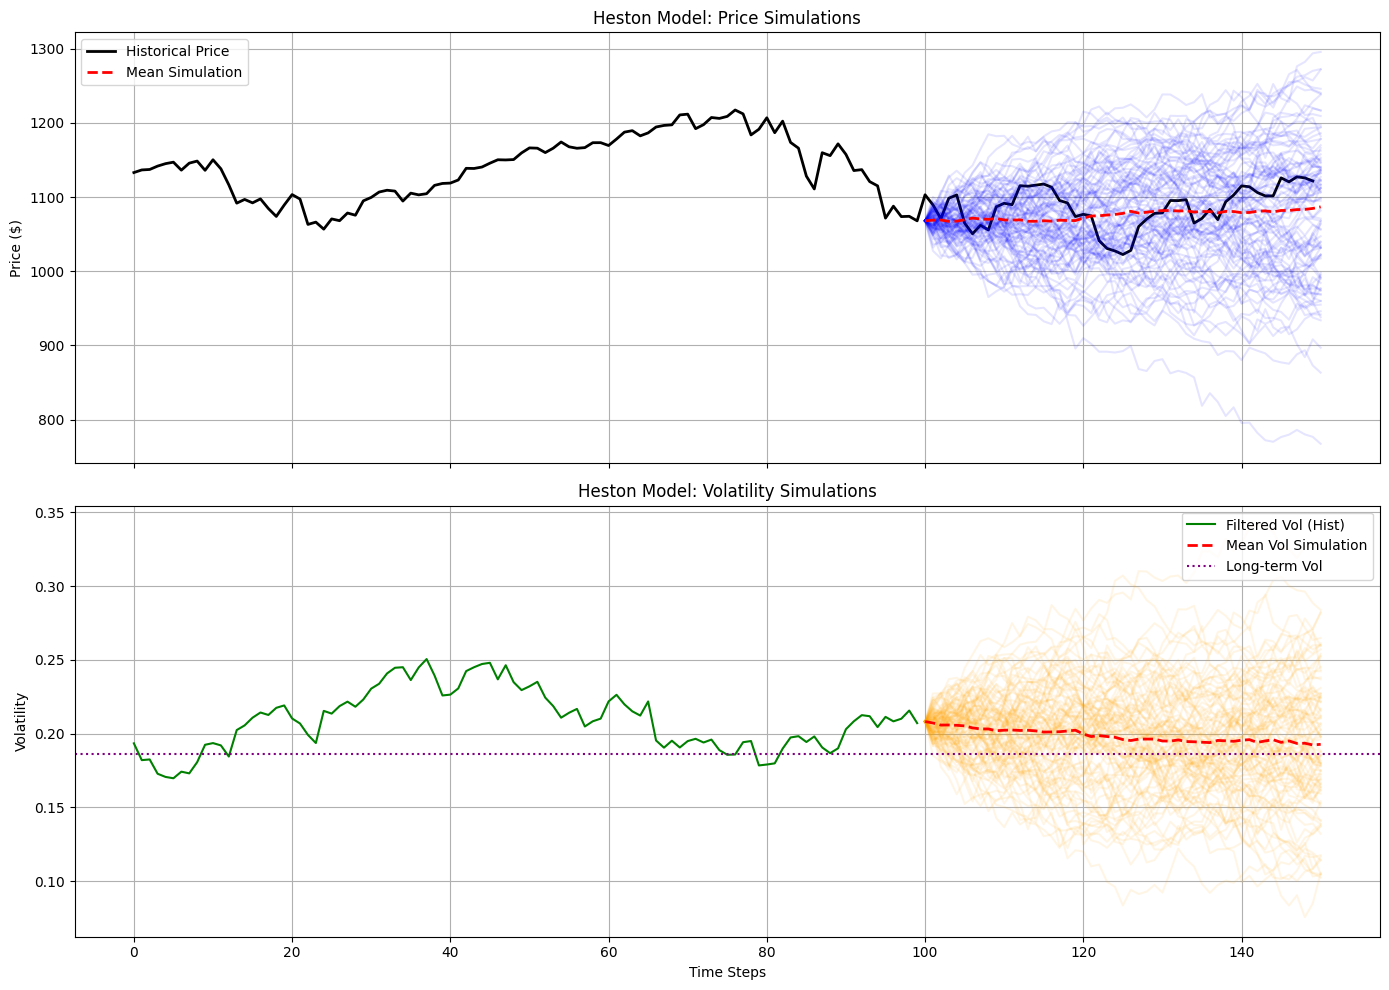

In [27]:
# 1. Подготовка данных
history_prices = df['SnP500'].values[:100] 
n_future_steps = 50
n_sims = 100

plot_rate = df['SnP500'].values[:100 + n_future_steps] 

# 2. Запуск симуляции
# use_filtered_start=True по умолчанию, что гарантирует старт с последней точки фильтра
hist_arr, price_sims, var_sims = Heston.simulate_future(
    history_prices=history_prices, 
    future_steps=n_future_steps, 
    n_simulations=n_sims,
    future_rates=None
)

# 3. Визуализация
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# --- График 1: Цены ---
t_hist = np.arange(len(plot_rate))
t_future = np.arange(len(hist_arr), len(hist_arr) + n_future_steps + 1)

ax1.plot(t_hist, plot_rate, label='Historical Price', color='black', linewidth=2)
for i in range(n_sims):
    ax1.plot(t_future, price_sims[i], alpha=0.1, color='blue') 
ax1.plot(t_future, np.mean(price_sims, axis=0), label='Mean Simulation', color='red', linestyle='--', linewidth=2)

ax1.set_title('Heston Model: Price Simulations')
ax1.set_ylabel('Price ($)')
ax1.legend(loc='upper left')
ax1.grid(True)

# --- График 2: Волатильность ---
# Получаем отфильтрованную волатильность за исторический период
v_hist_filtered = Heston.get_filtered_volatility_path()
# Берем последние len(hist_arr) точек, чтобы они совпали с осью X истории цен
# v_hist_filtered имеет длину T+1, где T - число доходностей. 
# hist_arr имеет длину N. Нужно аккуратно сопоставить индексы.
# Проще всего взять срез, соответствующий последним дням.
v_hist_plot = np.sqrt(v_hist_filtered[-len(hist_arr)-1:-1]) # Сдвиг из-за diff в расчетах

# Если длины не совпадают идеально из-за краевых эффектов diff, берем min
min_len = min(len(v_hist_plot), len(hist_arr))
v_hist_plot = v_hist_plot[:min_len]
t_rv_hist = np.arange(min_len)

ax2.plot(t_rv_hist, v_hist_plot, label='Filtered Vol (Hist)', color='green', linewidth=1.5)

# Симутации волатильности
vol_sims_sqrt = np.sqrt(var_sims)
t_fut_vol = np.arange(len(hist_arr), len(hist_arr) + n_future_steps + 1)

for i in range(n_sims):
    ax2.plot(t_fut_vol, vol_sims_sqrt[i], alpha=0.1, color='orange') 

mean_vol_sim = np.mean(vol_sims_sqrt, axis=0)
ax2.plot(t_fut_vol, mean_vol_sim, label='Mean Vol Simulation', color='red', linestyle='--', linewidth=2)
ax2.axhline(y=np.sqrt(Heston.theta), color='purple', linestyle=':', label=f'Long-term Vol')

ax2.set_title('Heston Model: Volatility Simulations')
ax2.set_xlabel('Time Steps')
ax2.set_ylabel('Volatility')
ax2.legend(loc='upper right')
ax2.grid(True)

plt.tight_layout()
plt.show()

# Калибровка поверхности подразумеваемой волатильности

## 1. Постановка задачи
Целью калибровки является построение гладкой функции $\sigma(K, T)$, описывающей подразумеваемую волатильность опционов в зависимости от цены страйка $K$ и срока до экспирации $T$. Поверхность строится на основе рыночных данных по опционам на ETF SPY (как прокси для индекса S&P 500) и кривой безрисковых ставок казначейских облигаций США.

## 2. Извлечение подразумеваемой волатильности (Implied Volatility)
Для каждого доступного опциона (Call/Put) с рыночной ценой $C_{mkt}$ или $P_{mkt}$ решается обратная задача уравнения Блэка-Шоулза. Подразумеваемая волатильность $\sigma_{imp}$ находится как корень нелинейного уравнения:

$$
V_{BS}(S_0, K, T, r, \sigma_{imp}) - V_{mkt} = 0
$$

где:
*   $S_0$ — текущая цена базового актива (получена из исторических данных SPX/SPY).
*   $r$ — безрисковая ставка, соответствующая сроку $T$ (интерполирована из кривой казначейских ставок).
*   $V_{BS}$ — теоретическая цена опциона по модели Блэка-Шоулза.
*   $V_{mkt}$ — среднее значение между ценой покупки и продажи (Mid-Price): $\frac{Bid + Ask}{2}$.

Минимизация квадрата невязки $(V_{BS} - V_{mkt})^2$ выполняется численно методом ограниченной оптимизации (L-BFGS-B) с начальным приближением $\sigma_0 = 0.2$.

## 3. Параметрическая модель поверхности
Для аппроксимации дискретного набора точек $\{(K_i, T_i, \sigma_{imp, i})\}$ используется параметрическая модель, учитывающая:
1.  **Базовый уровень волатильности** ($\alpha$).
2.  **Термальную структуру** (зависимость от времени до экспирации, $\beta$).
3.  **Улыбку волатильности** (зависимость от логарифмического манинесса, $\gamma$).

Функциональная форма модели:

$$
\sigma_{model}(K, T; \theta) = \alpha + \beta T + \gamma \left( \ln \left( \frac{K}{S_0} \right) \right)^2
$$

где $\theta = [\alpha, \beta, \gamma]$ — вектор калибруемых параметров.

## 4. Процедура калибровки
Оценка параметров $\hat{\theta}$ производится путем минимизации среднеквадратичной ошибки (MSE) между рыночными подразумеваемыми волатильностями и значениями, предсказанными моделью:

$$
\hat{\theta} = \arg \min_{\theta} \frac{1}{N} \sum_{i=1}^{N} \left( \sigma_{imp, i} - \sigma_{model}(K_i, T_i; \theta) \right)^2
$$

Оптимизация выполняется симплекс-методом Нелдера-Мида (Nelder-Mead), который устойчив к шуму в данных и не требует вычисления градиентов.

## 5. Результаты и интерпретация
*   **$\alpha$ (Base Vol):** Отражает ожидаемую волатильность для опционов "на деньгах" (ATM) с коротким сроком.
*   **$\beta$ (Term Structure):** Характеризует изменение волатильности при увеличении срока экспирации. Положительное значение указывает на рост неопределенности в долгосрочной перспективе.
*   **$\gamma$ (Smile Curvature):** Определяет крутизну "улыбки". Положительное значение подтверждает наличие эффекта улыбки волатильности, типичного для фондовых индексов (более высокая волатильность для глубоких OTM пут- и колл-опционов).

In [28]:
import numpy as np
import pandas as pd
import yfinance as yf
from scipy.optimize import minimize
from scipy.stats import norm
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import warnings

warnings.filterwarnings('ignore')

# --- Утилиты ---

def black_scholes_price(S, K, T, r, sigma, option_type='call'):
    if T <= 1e-10:
        return max(0.0, S - K) if option_type == 'call' else max(0.0, K - S)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option_type == 'call':
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

def implied_volatility_from_price(market_price, S, K, T, r, option_type='call'):
    if market_price <= 0: return np.nan
    if option_type == 'call':
        lower = max(0, S - K * np.exp(-r * T))
    else:
        lower = max(0, K * np.exp(-r * T) - S)
    if market_price < lower - 1e-6: return np.nan

    def objective(sigma):
        return (black_scholes_price(S, K, T, r, sigma, option_type) - market_price)**2
    
    res = minimize(objective, x0=0.2, bounds=[(1e-4, 4.0)], method='L-BFGS-B')
    return res.x[0] if res.success else np.nan

# --- Класс Калибровки с визуализацией ---

class VolatilitySurfaceCalibrator:
    def __init__(self, data_sp500, data_rates):
        self.data_sp500 = data_sp500.copy()
        self.data_rates = data_rates.copy()
        self.data_sp500['date'] = pd.to_datetime(self.data_sp500['date'])
        self.data_rates['date'] = pd.to_datetime(self.data_rates['date'])
        
        self.option_data = None
        self.calibrated_params = None
        self.is_calibrated = False
        self.calibration_report = ""
        self.spot_price = None # Сохраняем цену для графиков

    def load_option_surface(self, ticker='SPY', date=None):
        print(f"Loading option surface for {ticker}...")
        stock = yf.Ticker(ticker)
        expirations = stock.options
        if not expirations:
            raise ValueError("No options found.")
            
        all_options = []
        quote_date = pd.Timestamp(date) if date else pd.Timestamp.today()
        
        # Ограничим количество экспираций для скорости (например, первые 10)
        # Для полной поверхности нужно брать все
        target_expirations = expirations[:10] 
        
        for exp_date in target_expirations:
            try:
                chain = stock.option_chain(exp_date)
                calls = chain.calls
                puts = chain.puts
                
                if calls.empty and puts.empty: continue
                    
                calls['type'] = 'call'
                puts['type'] = 'put'
                calls['expiration'] = exp_date
                puts['expiration'] = exp_date
                calls['quote_date'] = quote_date
                puts['quote_date'] = quote_date
                
                all_options.append(calls)
                all_options.append(puts)
            except Exception:
                continue
                
        if not all_options:
            raise ValueError("No option data retrieved.")
            
        df_opts = pd.concat(all_options, ignore_index=True)
        df_opts['expiration'] = pd.to_datetime(df_opts['expiration'])
        df_opts['quote_date'] = pd.to_datetime(df_opts['quote_date'])
        df_opts['T'] = (df_opts['expiration'] - df_opts['quote_date']).dt.days / 365.0
        
        # Фильтрация
        df_opts = df_opts[(df_opts['T'] > 0.01) & (df_opts['T'] < 1.0)]
        
        self.option_data = df_opts
        print(f"Loaded {len(df_opts)} records.")

    def compute_implied_volatilities(self, spot_price=None, rate=None):
        if self.option_data is None:
            raise ValueError("Option data not loaded.")
            
        print("Computing IVs...")
        opts_df = self.option_data.copy()
        
        if spot_price is None or rate is None:
            quote_date = opts_df['quote_date'].iloc[0]
            sp500_row = self.data_sp500.iloc[(self.data_sp500['date'] - quote_date).abs().argsort()[:1]]
            rate_row = self.data_rates.iloc[(self.data_rates['date'] - quote_date).abs().argsort()[:1]]
            
            if sp500_row.empty or rate_row.empty:
                raise ValueError("No matching spot/rate data.")
                
            S = sp500_row['close'].values[0]
            r = rate_row['rate'].values[0]
        else:
            S = spot_price
            r = rate
            
        self.spot_price = S # Сохраняем для графиков
            
        opts_df['S'] = S
        opts_df['r'] = r
        opts_df['mid_price'] = (opts_df['bid'] + opts_df['ask']) / 2.0
        
        opts_df['IV'] = opts_df.apply(
            lambda row: implied_volatility_from_price(
                row['mid_price'], row['S'], row['strike'], row['T'], row['r'], row['type']
            ), 
            axis=1
        )
        
        opts_df.dropna(subset=['IV'], inplace=True)
        self.option_data = opts_df
        print(f"Computed IV for {len(opts_df)} options.")

    def calibrate_model(self):
        if self.option_data is None or 'IV' not in self.option_data.columns:
            raise ValueError("IVs not computed.")
            
        print("Calibrating...")
        df = self.option_data.copy()
        df['log_moneyness'] = np.log(df['strike'] / df['S'])
        df['log_moneyness_sq'] = df['log_moneyness'] ** 2
        
        def model_sigma(params, T, lm_sq):
            alpha, beta, gamma = params
            return np.maximum(1e-4, alpha + beta * T + gamma * lm_sq)
            
        def loss_function(params):
            pred_sigma = model_sigma(params, df['T'].values, df['log_moneyness_sq'].values)
            return np.mean((df['IV'].values - pred_sigma)**2)
            
        x0 = [0.2, 0.0, 0.5]
        result = minimize(loss_function, x0, method='Nelder-Mead', options={'maxiter': 2000})
        
        if result.success:
            self.calibrated_params = result.x
            self.is_calibrated = True
            self._generate_summary(result)
        else:
            raise RuntimeError(f"Calibration failed: {result.message}")
            
    def _generate_summary(self, opt_result):
        alpha, beta, gamma = self.calibrated_params
        self.calibration_report = f"""
========================================
       CALIBRATION REPORT
========================================
Model: Quadratic Smile Approximation
Formula: sigma(K, T) = alpha + beta*T + gamma*(ln(K/S))^2

Estimated Parameters:
----------------------------------------
alpha (Base Vol):     {alpha:.4f}
beta (Term Struct):   {beta:.4f}
gamma (Smile Curv):   {gamma:.4f}

Optimization Status:
----------------------------------------
Success: {opt_result.success}
Final Loss (MSE):     {opt_result.fun:.6f}
Number of Options:    {len(self.option_data)}
========================================
"""
        
    def summary(self):
        if not self.is_calibrated:
            return "Model not calibrated yet."
        return self.calibration_report

    def plot_surface(self):
        """
        Отрисовывает 3D поверхность калиброванной модели волатильности.
        """
        if not self.is_calibrated:
            raise ValueError("Calibrate the model first.")
            
        if self.spot_price is None:
            raise ValueError("Spot price not available.")
            
        alpha, beta, gamma = self.calibrated_params
        S = self.spot_price
        
        # Создаем сетку для графиков
        # Диапазон страйков: от 0.8*S до 1.2*S
        strikes = np.linspace(0.8 * S, 1.2 * S, 50)
        # Диапазон сроков: от 0.05 до 1.0 года
        times = np.linspace(0.05, 1.0, 50)
        
        K_grid, T_grid = np.meshgrid(strikes, times)
        
        # Вычисляем волатильность для каждой точки сетки
        log_moneyness_sq = (np.log(K_grid / S))**2
        sigma_grid = alpha + beta * T_grid + gamma * log_moneyness_sq
        
        # Визуализация
        fig = plt.figure(figsize=(12, 8))
        ax = fig.add_subplot(111, projection='3d')
        
        surf = ax.plot_surface(K_grid, T_grid, sigma_grid, cmap='viridis', edgecolor='none', alpha=0.9)
        
        ax.set_title('Calibrated Volatility Surface')
        ax.set_xlabel('Strike Price (K)')
        ax.set_ylabel('Time to Maturity (T)')
        ax.set_zlabel('Implied Volatility (sigma)')
        
        # Добавляем цветовую шкалу
        fig.colorbar(surf, shrink=0.5, aspect=10, label='Volatility')
        plt.tight_layout()
        
        plt.show()

In [32]:
calibrator.option_data

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,...,contractSize,currency,type,expiration,quote_date,T,S,r,mid_price,IV
868,SPY260430P00430000,2026-04-21 18:05:15+00:00,430.0,0.01,0.00,0.01,0.0,0.0,1.0,7014.0,...,REGULAR,USD,put,2026-04-30,2026-04-25 13:59:45.503715,0.010959,3839.5,0.04,0.005,0.2
869,SPY260430P00435000,2026-04-20 17:22:09+00:00,435.0,0.01,0.00,0.01,0.0,0.0,1.0,875.0,...,REGULAR,USD,put,2026-04-30,2026-04-25 13:59:45.503715,0.010959,3839.5,0.04,0.005,0.2
870,SPY260430P00440000,2026-04-24 15:09:15+00:00,440.0,0.01,0.00,0.01,0.0,0.0,4.0,628.0,...,REGULAR,USD,put,2026-04-30,2026-04-25 13:59:45.503715,0.010959,3839.5,0.04,0.005,0.2
871,SPY260430P00445000,2026-04-15 15:22:09+00:00,445.0,0.02,0.00,0.01,0.0,0.0,8.0,2423.0,...,REGULAR,USD,put,2026-04-30,2026-04-25 13:59:45.503715,0.010959,3839.5,0.04,0.005,0.2
872,SPY260430P00450000,2026-04-23 15:22:43+00:00,450.0,0.01,0.00,0.01,0.0,0.0,220.0,19513.0,...,REGULAR,USD,put,2026-04-30,2026-04-25 13:59:45.503715,0.010959,3839.5,0.04,0.005,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2956,SPY260529P00855000,2026-04-07 19:45:54+00:00,855.0,195.95,139.88,142.70,0.0,0.0,NaN,0.0,...,REGULAR,USD,put,2026-05-29,2026-04-25 13:59:45.503715,0.090411,3839.5,0.04,141.290,0.2
2957,SPY260529P00865000,2026-03-23 19:41:05+00:00,865.0,207.29,149.88,152.70,0.0,0.0,NaN,0.0,...,REGULAR,USD,put,2026-05-29,2026-04-25 13:59:45.503715,0.090411,3839.5,0.04,151.290,0.2
2958,SPY260529P00870000,2026-03-23 18:08:04+00:00,870.0,213.00,154.88,157.70,0.0,0.0,NaN,0.0,...,REGULAR,USD,put,2026-05-29,2026-04-25 13:59:45.503715,0.090411,3839.5,0.04,156.290,0.2
2959,SPY260529P00885000,2026-03-23 19:38:40+00:00,885.0,227.32,169.88,172.70,0.0,0.0,NaN,0.0,...,REGULAR,USD,put,2026-05-29,2026-04-25 13:59:45.503715,0.090411,3839.5,0.04,171.290,0.2


In [31]:
# --- Пример использования ---

# 1. Подготовьте ваши данные
dates = pd.date_range('2026-04-20', '2026-04-24', freq='D')
df_sp500 = df[['Date', 'SnP500']].rename(columns = {'Date' : 'date', 'SnP500' : 'close'})
df_rates = df[['Date', 'rate']].rename(columns = {'Date' : 'date'})

calibrator = VolatilitySurfaceCalibrator(df_sp500, df_rates)

# 2. Загружаем поверхность (используем SPY, так как ^SPX часто недоступен)
calibrator.load_option_surface(ticker='SPY')

# 3. Считаем IV (автоматически возьмет цену из df_sp500 за ближайшую дату)
calibrator.compute_implied_volatilities()

# 4. Калибруем
calibrator.calibrate_model()

# 5. Вывод
print(calibrator.summary())

Loading option surface for SPY...
Loaded 2304 records.
Computing IVs...
Computed IV for 1115 options.
Calibrating...

       CALIBRATION REPORT
Model: Quadratic Smile Approximation
Formula: sigma(K, T) = alpha + beta*T + gamma*(ln(K/S))^2

Estimated Parameters:
----------------------------------------
alpha (Base Vol):     0.2423
beta (Term Struct):   0.0015
gamma (Smile Curv):   -0.0125

Optimization Status:
----------------------------------------
Success: True
Final Loss (MSE):     0.000053
Number of Options:    1115



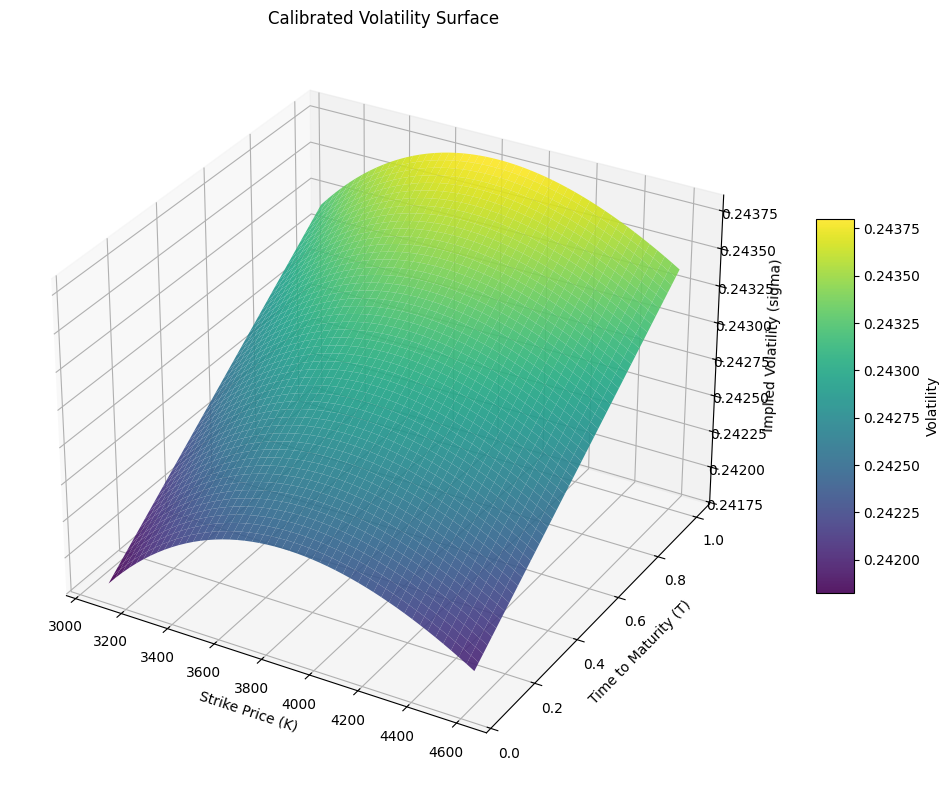

In [33]:
calibrator.plot_surface()